## Inciso a) 


Para determinar la dimensión del espacio de Hilbert del sistema completo, debemos considerar los espacios de las partículas individuales.

Cada espín 1/2 tiene un espacio de Hilbert local de dimensión 2, correspondiente a sus dos estados base $|\uparrow \rangle = [1,0]^T$ y $|\downarrow \rangle = [0,1]^T$

Para un sistema cuántico compuesto por N de estas partículas, el espacio de Hilbert total $$\mathcal{H} se construye como el producto tensorial de los espacios individuales.
Dado que la dimensión del producto tensorial es el producto de las dimensiones de cada espacio, y para cada espín la dimendión es de 2, la dimensión total en función de $N$ es:

$\dim(\mathcal{H}) = 2\times2\times2\times...\times2 = 2^N$

In [ ]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import time

'''Inciso b)'''
h_bar = 1
Id = np.eye(2,dtype= 'float') 
sig_x = np.array([[0,1],[1,0]],dtype='float')
sig_z = np.array([[1,0],[0,-1]],dtype='float')

def Prod_tens(l,N,mtr):
    lista_temp = np.array([Id]*N)
    lista_temp[l-1] = mtr 
    prod = lista_temp[0]
    for i in range(1,N): 
        mtz_1 = lista_temp[i]
        prod = np.kron(prod,mtz_1)
    return prod

def sumas_mtr_x(N,mtr):
    suma = np.zeros((2**N,2**N))
    sig_1 = Prod_tens(1,N,mtr)
    for i in range(N-1):
        sig_2 = Prod_tens(i+2,N,mtr) 
        multed_sig = np.dot(sig_1,sig_2)   
        suma += multed_sig  
        sig_1 = sig_2    
    return suma

def sumas_mtr_z(N,mtr):
    suma = np.zeros((2**N,2**N)) 
    for i in range(N):
        sig_1 = Prod_tens(i+1,N,mtr) 
        suma += sig_1    
    return suma

#La función que utilizamos para definir el Hamiltoniano
def Hamilton(N,J,B):
    H_J = J*sumas_mtr_x(N,sig_x)
    H_B = B*sumas_mtr_z(N,sig_z)
    H = H_J + H_B
    return H
N = 3
J = 1
B = 1
H = Hamilton(N,J,B)
print(H)


[[ 3.  0.  0.  1.  0.  0.  1.  0.]
 [ 0.  1.  1.  0.  0.  0.  0.  1.]
 [ 0.  1.  1.  0.  1.  0.  0.  0.]
 [ 1.  0.  0. -1.  0.  1.  0.  0.]
 [ 0.  0.  1.  0.  1.  0.  0.  1.]
 [ 0.  0.  0.  1.  0. -1.  1.  0.]
 [ 1.  0.  0.  0.  0.  1. -1.  0.]
 [ 0.  1.  0.  0.  1.  0.  0. -3.]]


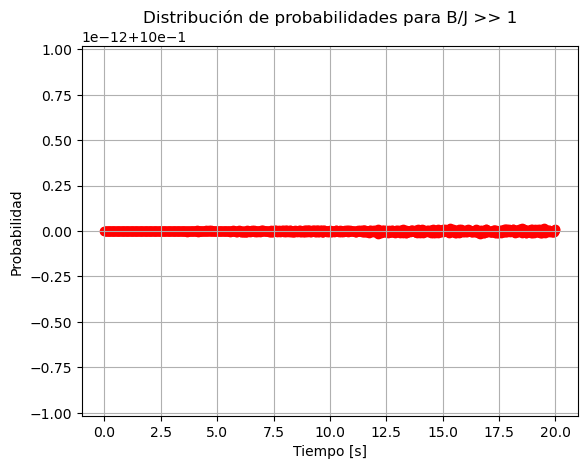

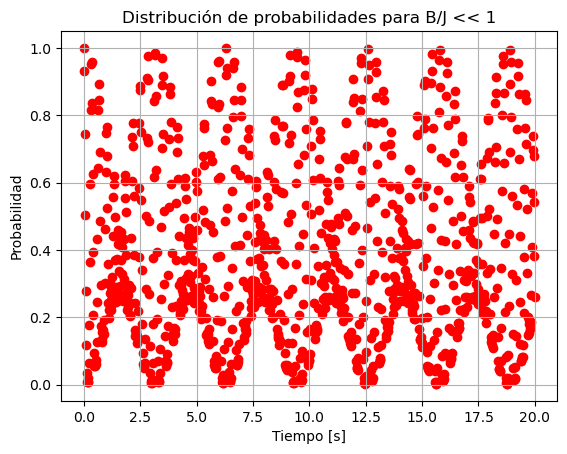

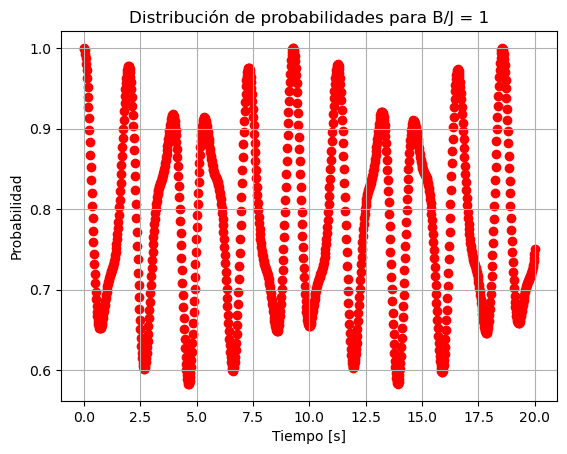

In [13]:
'''Inciso c)'''
#La función pare crear el estado inicial
def psi_0(N):
    mtr = np.array([0,1])
    nr = np.array([0,1])
    for i in range(N-1):
        mtr = np.kron(mtr,nr)
    return mtr

#La función para el psi(x,t)
def psi_t(t,N,H):
    R = range(len(t))
    psi_in = psi_0(N)
    psi_results = []
    for i in R:
        U = scipy.linalg.expm(-1j*H*t[i]/h_bar)
        psi = U@psi_in 
        psi_results.append(psi)

    return psi_results

#Función para calcular la probabilidad de retornar al estado inicial
def prob(N,psi_temp):
    D = range(len(psi_temp))
    x = psi_0(N)
    dummy_list = []
    for i in D:
        l = np.abs(psi_temp[i]@x)**2
        dummy_list.append(l)
    return dummy_list


time_space = np.linspace(0, 20, 1000) #para graficar en el tiempo

# Para B/J >> 1 
N = 3
B = 1
J = 10e-9
H = Hamilton(N,J,B)
psi_temp = psi_t(time_space,N,H)
Probabilidad = prob(N,psi_temp)
plt.scatter(time_space,Probabilidad, color= 'red')
plt.grid()
plt.title(f"Distribución de probabilidades para B/J >> 1")
plt.xlabel('Tiempo [s]')
plt.ylabel('Probabilidad')
plt.show()

# Para B/J << 1 
N = 3
B = 1
J = 10e9
H = Hamilton(N,J,B)
psi_temp = psi_t(time_space,N,H)
Probabilidad = prob(N,psi_temp)
plt.scatter(time_space,Probabilidad, color= 'red')
plt.grid()
plt.title(f"Distribución de probabilidades para B/J << 1")
plt.xlabel('Tiempo [s]')
plt.ylabel('Probabilidad')
plt.show()

# Para B/J << 1 
N = 3
B = 1
J = 1
H = Hamilton(N,J,B)
psi_temp = psi_t(time_space,N,H)
Probabilidad = prob(N,psi_temp)
plt.scatter(time_space,Probabilidad, color= 'red')
plt.grid()
plt.title(f"Distribución de probabilidades para B/J = 1")
plt.xlabel('Tiempo [s]')
plt.ylabel('Probabilidad')
plt.show()


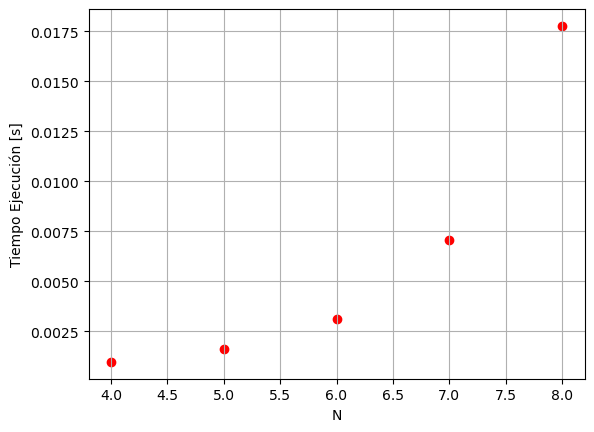

In [ ]:
'''Inciso d) y e)'''


N = [4,5,6,7,8]
J = 1
B = 1

repeticiones = 100 
lista_tiempos_ejecución = []
for j in range(len(N)):
    tiempo = 0
    for i in range(repeticiones):
        t_1 = time.perf_counter()
        Hamilton(N[j],J,B)
        t_2 = time.perf_counter()
        tiempo += t_2-t_1
    tiempo = tiempo/repeticiones
    lista_tiempos_ejecución.append(tiempo)

plt.scatter(N,lista_tiempos_ejecución, color= 'red')
plt.grid()
plt.xlabel('N')
plt.ylabel('Tiempo Ejecución [s]')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


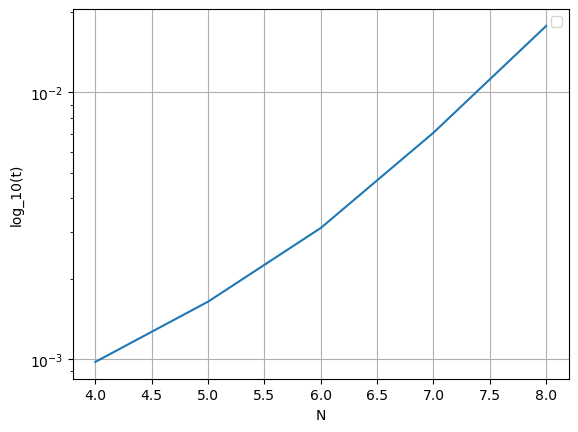

Pendiente experimental tiempo: 0.32
Intercepto experimental tiempo: -4.34
 Estimaciones de tiempo de ejecución para N = 20: 94.95502196033529, N = 50: 279628470926.0462, N = 100: 1.6918186315465172e+27 
 Comparación de tiempos para N = 20: 4.2999999999999994e+17, N = 50: 4.299997203715291e+17, N = 100: -1.6918186311165172e+27 


In [ ]:
'''Inciso f) y g)'''

#Ley de potencia, el tiempo T escala como A^N con A una cte. Por eso buscamos linealizar T
#y encontrar una pendiente e intercepto para poder estimar los tiempos de ejecución. Similar a lo que se hace
#En el problema 2 de la tarea.
plt.plot(N,lista_tiempos_ejecución)
plt.yscale('log') 
plt.xlabel('N')
plt.ylabel('log_10(T)')
plt.show()

log_t = np.log10(lista_tiempos_ejecución)

pendiente_t, intercepto_t = np.polyfit(N, log_t,1)
print(f"Pendiente experimental tiempo: {pendiente_t:.2f}")
print(f"Intercepto experimental tiempo: {intercepto_t:.2f}")

N_new = [20,50,100]
estimaciones = []
diferencias = []
edad_universo = 4.3e17
for i in N_new:
    estimacion = 10**(pendiente_t*i + intercepto_t)
    diferencias = edad_universo - estimacion
    diferencias.append(diferencias)
    estimaciones.append(estimacion) 

print(f" Estimaciones de tiempo de ejecución para N = 20: {estimaciones[0]}, N = 50: {estimaciones[1]}, N = 100: {estimaciones[2]} ")
print(f" Diferencias de tiempos para N = 20: {diferencias[0]}, N = 50: {diferencias[1]}, N = 100: {diferencias[2]} ")


## Inciso h)

El hecho de que el espacio de Hilbert crezca como $2^N$ representa un cuello de botella gigante. Tomando simplemente el caso de $N = 50$ ya tenemos $2^{50} \approx 10^{15} $ números que deben ser guardados en la memoria RAM. Esto ya de por si es un problema grande pero, por si fuera poco, estos números son números complejos los cuáles ocupan $16$ bytes de memoria cada uno.

Entonces se necesitarían $10^{15}\times 16 \approx 18$ Petabytes de memoria RAM para poder realizar el cálculo. Tal cantidad de memoria es descomunal y en lo absoluto viable para un solo computador.

Y ese es solo el problema de la RAM, **SUPONIENDO** que un computador tuviese esa cantidad de memoria luego está la cantidad de tiempo que le tomaría al computador hacer el cálculo de la matriz. Para este mismo caso de $N = 50$ pueden verse la cantidad de segundos que tomaría en el bloque de arriba. Y ya para $N = 100$ simplemente no ha pasado la cantidad de tiempo suficiente en la historia del universo observable para hacer el cálculo. 